# Classification des espèces — Le Panier-Sûr

Entraînement et comparaison de deux modèles pour prédire l'espèce (`nom`) d'un champignon à partir de ses caractéristiques morphologiques, d'habitat et de saisonnalité.

**Modèles comparés :**
- **A — Arbre de Décision** (`DecisionTreeClassifier`) : règles interprétables, visualisables.
- **B — Forêt Aléatoire** (`RandomForestClassifier`) : meilleure précision, robuste au bruit.

**Dataset :** `data/clean_train_data/champignons_augmented.csv` (217 espèces × 1000 exemplaires = 217 000 lignes).

## 1. Imports et chargement

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

RANDOM_STATE = 42
DATA_CSV = "../data/clean_train_data/champignons_augmented.csv"

df = pd.read_csv(DATA_CSV)
print(f"{df.shape[0]:,} lignes, {df.shape[1]} colonnes — {df['nom'].nunique()} espèces")
df.head(3)

217,000 lignes, 165 colonnes — 217 espèces


,nom,statut,chapeau_taille_min_cm,chapeau_taille_max_cm,pied_taille_min_cm,pied_taille_max_cm,a_un_chapeau,a_des_pores,a_des_lames,a_un_pied,...,saison_mois_03,saison_mois_04,saison_mois_05,saison_mois_06,saison_mois_07,saison_mois_08,saison_mois_09,saison_mois_10,saison_mois_11,saison_mois_12
0,AGARIC AUGUSTE,Champignon à rejeter,14.703587,16.523585,11.418172,17.371579,1,0,1,1,...,0,0,0,0,0,0,0,1,0,0
1,AGARIC AUGUSTE,Champignon à rejeter,9.800079,11.353565,10.669428,15.406923,1,0,1,1,...,0,0,0,0,0,0,0,1,0,0
2,AGARIC AUGUSTE,Champignon à rejeter,12.927635,18.752256,14.519034,19.881446,1,0,1,1,...,0,0,0,0,0,1,0,0,0,0


## 2. Préparation : X / y, encodage, split stratifié

- **Cible** : `nom` (nom de l'espèce) → encodée via `LabelEncoder` (217 classes entières).
- **Features** : toutes les colonnes sauf `nom` et `statut` (le statut est une autre cible possible, on l'exclut des features pour éviter toute fuite).
- **One-Hot Encoding** : les features sont déjà binaires/numériques après la phase de *transform*. On applique `pd.get_dummies` par sécurité pour encoder toute colonne objet résiduelle (no-op attendu).
- **Split** : 80 % train / 20 % test avec `stratify=y` pour garantir que chaque espèce apparaît dans les deux sets.

In [2]:
# --- Séparation features / cible ---
TARGET = "nom"
EXCLUDE = ["nom", "statut"]

X = df.drop(columns=EXCLUDE)
y_raw = df[TARGET]

# --- One-Hot Encoding des éventuelles colonnes catégorielles (no-op ici) ---
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
if cat_cols:
    print(f"Encodage OHE de {len(cat_cols)} colonnes catégorielles : {cat_cols}")
    X = pd.get_dummies(X, columns=cat_cols, drop_first=False)
else:
    print("Aucune colonne catégorielle à encoder — features déjà numériques.")

# --- LabelEncoder sur la cible ---
le = LabelEncoder()
y = le.fit_transform(y_raw)
print(f"Cible encodée : {len(le.classes_)} classes")

# --- Split stratifié 80/20 ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train : {X_train.shape} | Test : {X_test.shape}")
print(f"Classes uniques dans train : {len(np.unique(y_train))} | dans test : {len(np.unique(y_test))}")

Aucune colonne catégorielle à encoder — features déjà numériques.
Cible encodée : 217 classes
Train : (173600, 163) | Test : (43400, 163)
Classes uniques dans train : 217 | dans test : 217


## 3. Modèle A — Arbre de Décision

Un `DecisionTreeClassifier` est entraîné sans limitation de profondeur (l'arbre grandit jusqu'à séparer toutes les classes). Rapide à entraîner, facile à inspecter.

In [3]:
tree_clf = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree_clf.fit(X_train, y_train)

y_pred_tree = tree_clf.predict(X_test)
acc_tree = accuracy_score(y_test, y_pred_tree)
print(f"[Decision Tree] Accuracy : {acc_tree:.4f}")
print(f"[Decision Tree] Profondeur : {tree_clf.get_depth()} | Feuilles : {tree_clf.get_n_leaves()}")

# Classification report (217 classes → long, on le tronque à quelques lignes)
report_tree = classification_report(
    y_test, y_pred_tree, target_names=le.classes_, zero_division=0
)
print("\n--- Classification report (aperçu) ---")
lines = report_tree.split("\n")
print("\n".join(lines[:8] + ["..."] + lines[-4:]))

[Decision Tree] Accuracy : 1.0000
[Decision Tree] Profondeur : 37 | Feuilles : 217

--- Classification report (aperçu) ---
                                 precision    recall  f1-score   support

                 AGARIC AUGUSTE       1.00      1.00      1.00       200
            AGARIC DES JACHÈRES       1.00      1.00      1.00       200
              AGARIC JAUNISSANT       1.00      1.00      1.00       200
               AGARIC SYLVICOLE       1.00      1.00      1.00       200
                AMANITE CITRINE       1.00      1.00      1.00       200
                  AMANITE FAUVE       1.00      1.00      1.00       200
...
                       accuracy                           1.00     43400
                      macro avg       1.00      1.00      1.00     43400
                   weighted avg       1.00      1.00      1.00     43400



## 4. Modèle B — Forêt Aléatoire

`RandomForestClassifier` avec 100 arbres. `n_jobs=-1` utilise tous les cœurs CPU pour accélérer l'entraînement.

In [4]:
rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"[Random Forest] Accuracy : {acc_rf:.4f}")

report_rf = classification_report(
    y_test, y_pred_rf, target_names=le.classes_, zero_division=0
)
print("\n--- Classification report (aperçu) ---")
lines = report_rf.split("\n")
print("\n".join(lines[:8] + ["..."] + lines[-4:]))

[Random Forest] Accuracy : 1.0000

--- Classification report (aperçu) ---
                                 precision    recall  f1-score   support

                 AGARIC AUGUSTE       1.00      1.00      1.00       200
            AGARIC DES JACHÈRES       1.00      1.00      1.00       200
              AGARIC JAUNISSANT       1.00      1.00      1.00       200
               AGARIC SYLVICOLE       1.00      1.00      1.00       200
                AMANITE CITRINE       1.00      1.00      1.00       200
                  AMANITE FAUVE       1.00      1.00      1.00       200
...
                       accuracy                           1.00     43400
                      macro avg       1.00      1.00      1.00     43400
                   weighted avg       1.00      1.00      1.00     43400



### Comparaison des deux modèles

In [5]:
comparison = pd.DataFrame({
    "Modèle": ["Decision Tree", "Random Forest"],
    "Accuracy": [acc_tree, acc_rf],
})
comparison["Accuracy"] = comparison["Accuracy"].map(lambda v: f"{v:.4f}")
print(comparison.to_string(index=False))

       Modèle Accuracy
Decision Tree   1.0000
Random Forest   1.0000


## 5. Visualisation des règles de décision (3 premiers niveaux)

Avec 217 classes, l'arbre complet est illisible. On affiche les **3 premiers niveaux** pour comprendre quels critères discriminent le plus tôt (couleur dominante, présence d'anneau, type d'habitat…).

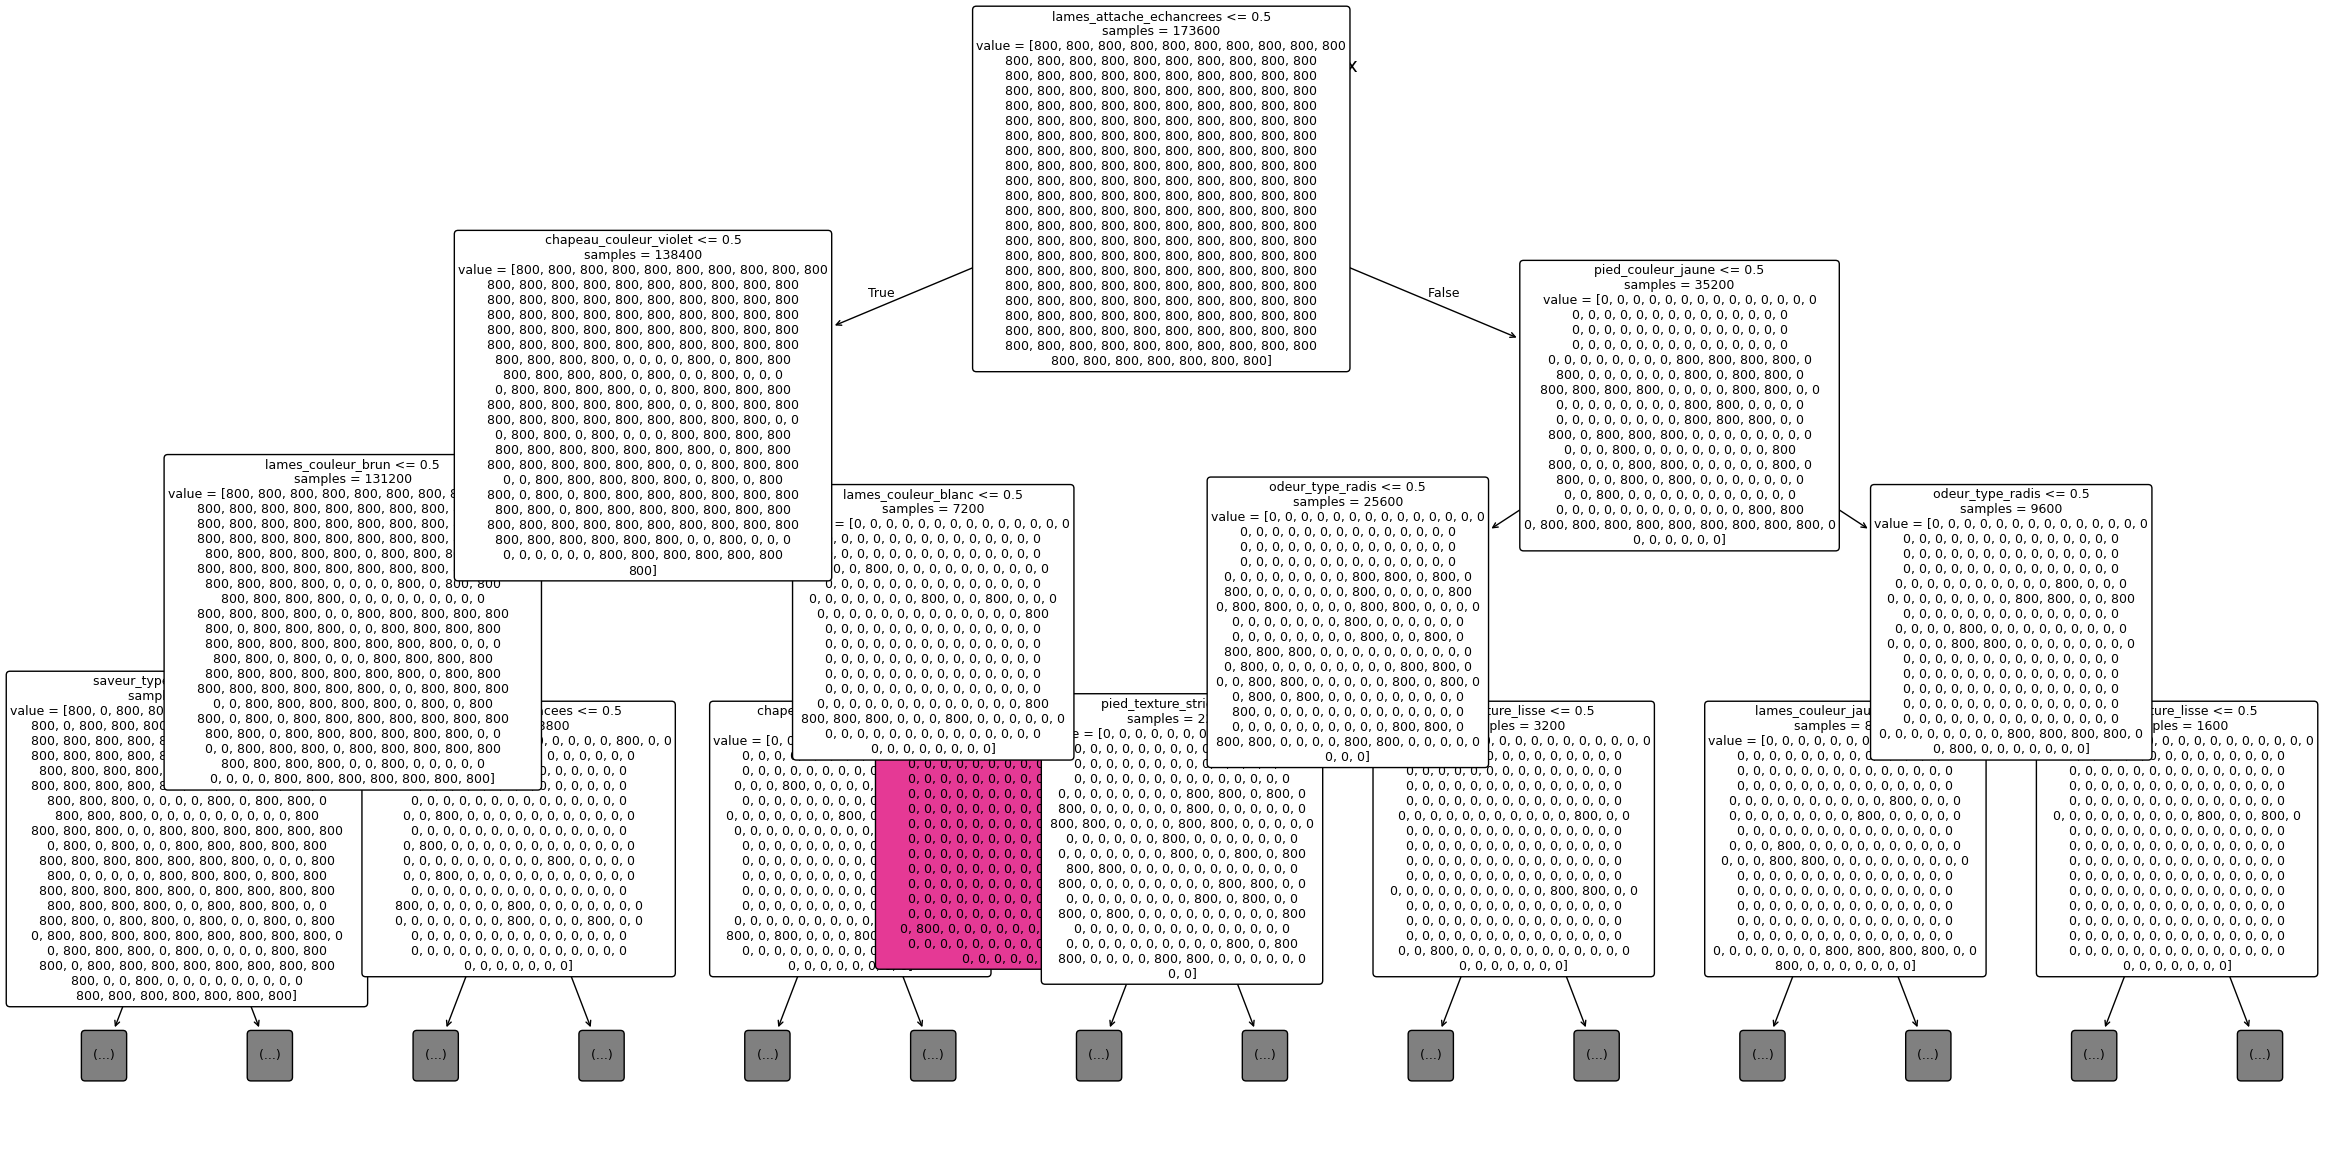

In [6]:
fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(
    tree_clf,
    max_depth=3,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=9,
    impurity=False,
    ax=ax,
)
ax.set_title("Decision Tree — 3 premiers niveaux", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Importance des caractéristiques

On utilise les `feature_importances_` de la Forêt Aléatoire (plus stables que celles d'un seul arbre). On affiche les **20 features les plus discriminantes** : on devrait y voir principalement des couleurs, des morphologies de pied (anneau, volve), des odeurs/saveurs, et les tailles.

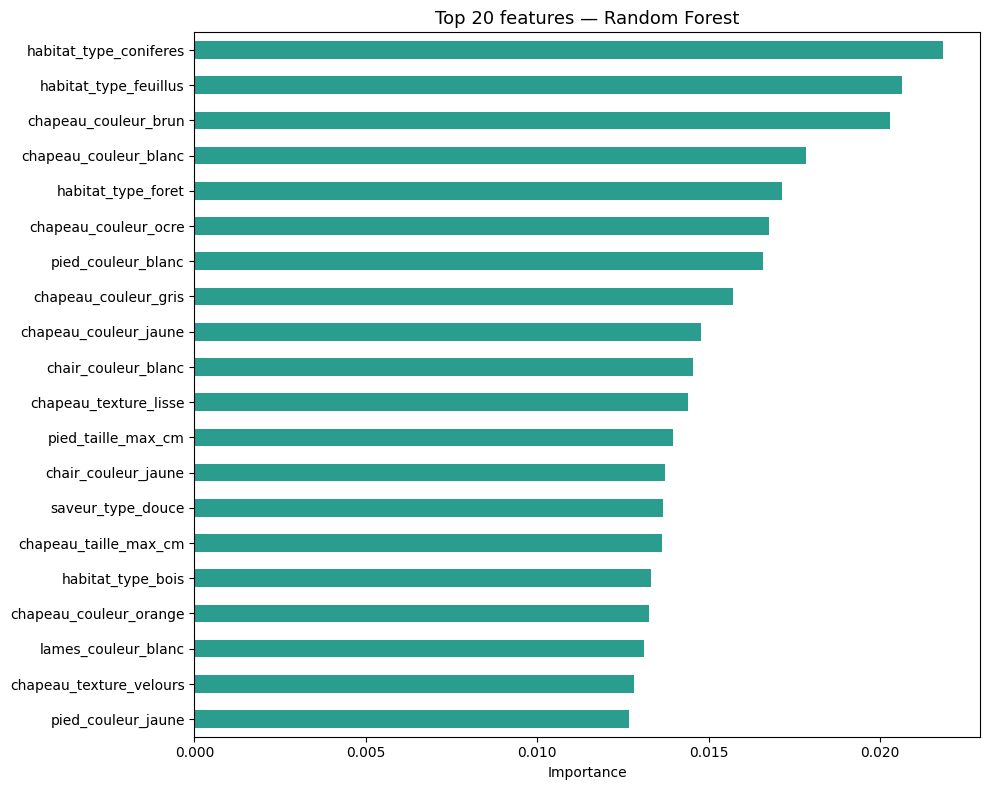


Top 20 features :
habitat_type_coniferes     0.021822
habitat_type_feuillus      0.020653
chapeau_couleur_brun       0.020298
chapeau_couleur_blanc      0.017841
habitat_type_foret         0.017129
chapeau_couleur_ocre       0.016768
pied_couleur_blanc         0.016587
chapeau_couleur_gris       0.015707
chapeau_couleur_jaune      0.014770
chair_couleur_blanc        0.014531
chapeau_texture_lisse      0.014405
pied_taille_max_cm         0.013972
chair_couleur_jaune        0.013715
saveur_type_douce          0.013667
chapeau_taille_max_cm      0.013634
habitat_type_bois          0.013308
chapeau_couleur_orange     0.013272
lames_couleur_blanc        0.013122
chapeau_texture_velours    0.012830
pied_couleur_jaune         0.012668


In [7]:
importances = pd.Series(rf_clf.feature_importances_, index=X.columns)
top = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
top[::-1].plot(kind="barh", ax=ax, color="#2a9d8f")
ax.set_xlabel("Importance")
ax.set_title("Top 20 features — Random Forest", fontsize=13)
plt.tight_layout()
plt.show()

print("\nTop 20 features :")
print(top.to_string())

## 7. Synthèse

- L'**Arbre de Décision** donne une lecture directe des règles : utile pour expliquer une prédiction (« ce champignon a été classé *Amanite phalloïde* parce qu'il a un anneau, une volve et des lames blanches »).
- La **Forêt Aléatoire** agrège 100 arbres entraînés sur des sous-échantillons → réduit la variance, améliore la précision, et fournit une mesure d'importance plus stable.

**Prochaines pistes :** grid-search sur `max_depth` / `n_estimators`, matrice de confusion restreinte aux espèces dangereuses (mortelles / toxiques), modèle hiérarchique `statut` → `nom`.